<a href="https://colab.research.google.com/github/kennethkvs/RetinalDiseasesOCTClassifier/blob/main/RetinalDiseaseOCTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPSCI 4AL3 Project: Retinal Disease OCT Classifier

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from PIL import Image
import sklearn
import matplotlib.pyplot as plt

# PyTorch Imports
import torch
from torchvision.transforms import v2 as image_preprocess
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# Sklearn Imports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matplotlib Imports
from matplotlib import cm

## Preprocessing Dataset

#### Resources Used

- https://docs.pytorch.org/vision/main/transforms.html
- GitHub Copilot Autocomplete was used to help construct some sections of the code, in addition to helping autocomplete some redundent code elements that were already present in the code and just needed to be written again and writing the comments seen throughout the code. Since data is not available regarding the carbon emissions of GitHub Copilot autocomplete, I will be treating each autocomplete as a ChatGPT querry as GitHub Copilot is powered by ChatGPT. Therefore, using the provided metric of 4.32g of carbon emissions for a ChatGPT querry, we will be estimating my total carbon emission for using GitHub Copilot autocomplete for comments and writing redudent code at 4.32g x 20 = 86.4g.

In [2]:
# Dataset Class Definition
class OCTImageDataset:
    def __init__(self, data_dir: str, type: str):
        self.data_dir = data_dir
        self.type = type
        self.label_mapping = {
            'CNV': 0,
            'DME': 1,
            'DRUSEN': 2,
            'NORMAL': 3
        }
        self.image_paths = []
        self.classes = list(self.label_mapping.keys())
        self.labels = []
        self.image_processor = None

        # Initialize class attributes
        match type:
            case 'train':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Different transformations
                    image_preprocess.RandomHorizontalFlip(),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case 'test' | 'val':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case _:
                raise ValueError("Type must be 'train', 'val', or 'test'.")
        self.load_data()

    def load_data(self):
        for label in os.listdir(self.data_dir):
            label_dir = os.path.join(self.data_dir, label)
            if os.path.isdir(label_dir):
                for image_file in os.listdir(label_dir):
                    if image_file.endswith(('.png', '.jpg', '.jpeg')):
                        image_path = os.path.join(label_dir, image_file)
                        self.image_paths.append(image_path)
                        self.labels.append(self.label_mapping[label])
        
        print(f"Loaded {len(self.image_paths)} images for {self.type} set.")

    def visualize(self):
        # Print out dataset statistics
        class_counts = {
            'CNV': self.labels.count(0),
            'DME': self.labels.count(1),
            'DRUSEN': self.labels.count(2),
            'NORMAL': self.labels.count(3)
        }
        print(f"Visualizing dataset statistics for {self.type} set:")
        for class_name, count in class_counts.items():
            print(f"{class_name}: {count} images")
        
        # Plot class distribution
        plt.bar(class_counts.keys(), class_counts.values())
        plt.title(f'Class Distribution in {self.type} Set')
        plt.xlabel('Classes')
        plt.ylabel('Number of Images')
        plt.show()

        # Display sample images from each class
        plt.figure(figsize=(12, 6))
        for class_name in self.classes:
            # Pick the first image from each class for visualization
            image_path = os.path.join(self.data_dir, class_name, os.listdir(os.path.join(self.data_dir, class_name))[0])
            image = Image.open(image_path)
            plt.subplot(1, 4, self.label_mapping[class_name] + 1)
            plt.imshow(image, cmap='gray') # Image data is grayscale idk why without cmap it isn't grayscale
            plt.title(class_name)
        plt.show()

    # Needed for PyTorch DataLoader compatibility
    def __len__(self):
        if len(self.image_paths) != len(self.labels):
            raise ValueError("Mismatch between number of images and labels.")
        if len(self.image_paths) == 0 or len(self.labels) == 0:
            raise ValueError("No images found in the dataset.")

        return len(self.image_paths)
    
    # Needed for PyTorch DataLoader compatibility
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')
        if self.image_processor:
            image = self.image_processor(image)
        else:
            raise ValueError("Image processor not defined.")
        
        return image, label


In [3]:
# Data Configurations
batch_size = 64
shuffle_data = True
# train_data_dir = 'Dataset/train'
# test_data_dir = 'Dataset/test'
# val_data_dir = 'Dataset/val'

train_data_dir = '1000_images_only/train'
test_data_dir = '1000_images_only/test'
val_data_dir = '1000_images_only/val'

Loaded 4000 images for train set.
Visualizing dataset statistics for train set:
CNV: 1000 images
DME: 1000 images
DRUSEN: 1000 images
NORMAL: 1000 images


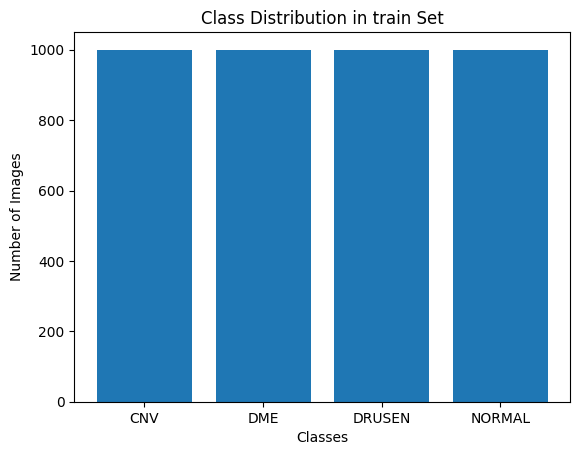

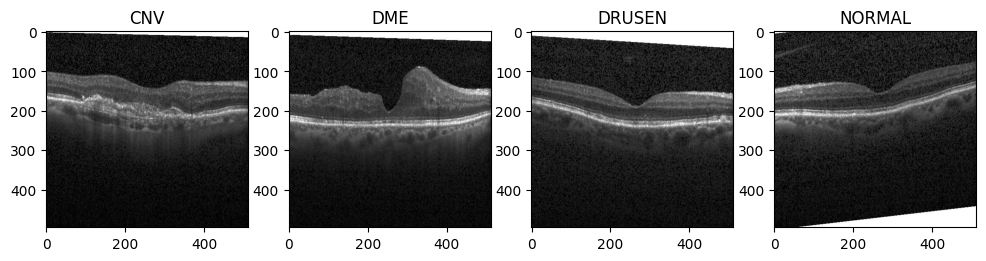

Sample training data tensor
(Image([[[ 2.1975,  2.1975,  2.2147,  ...,  2.2489,  2.2489,  2.2489],
        [-0.2513, -0.3027, -0.1143,  ...,  2.2489,  2.2489,  2.2489],
        [-1.6898, -1.6898, -1.5699,  ...,  2.2489,  2.2489,  2.2489],
        ...,
        [-2.0494, -2.0152, -2.0323,  ..., -2.0665, -2.0152, -2.0323],
        [-2.0152, -2.0152, -2.0665,  ..., -1.9809, -2.0152, -2.0152],
        [-2.0665, -2.0152, -2.0323,  ..., -2.0152, -2.0837, -2.0323]],

       [[ 2.3761,  2.3761,  2.3936,  ...,  2.4286,  2.4286,  2.4286],
        [-0.1275, -0.1800,  0.0126,  ...,  2.4286,  2.4286,  2.4286],
        [-1.5980, -1.5980, -1.4755,  ...,  2.4286,  2.4286,  2.4286],
        ...,
        [-1.9657, -1.9307, -1.9482,  ..., -1.9832, -1.9307, -1.9482],
        [-1.9307, -1.9307, -1.9832,  ..., -1.8957, -1.9307, -1.9307],
        [-1.9832, -1.9307, -1.9482,  ..., -1.9307, -2.0007, -1.9482]],

       [[ 2.5877,  2.5877,  2.6051,  ...,  2.6400,  2.6400,  2.6400],
        [ 0.0953,  0.0431,  0.2

In [4]:
# Training Dataset Initialization
training_data = OCTImageDataset(data_dir=train_data_dir, type='train')
training_data.visualize()
print(f'Sample training data tensor\n{training_data[0]}')

# Training Data Loader
training_data_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 968 images for test set.
Visualizing dataset statistics for test set:
CNV: 242 images
DME: 242 images
DRUSEN: 242 images
NORMAL: 242 images


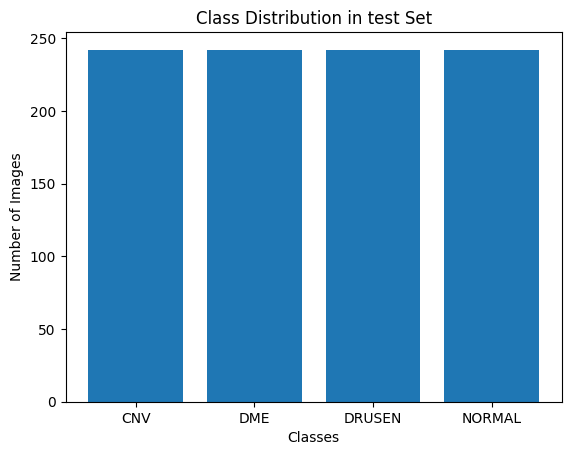

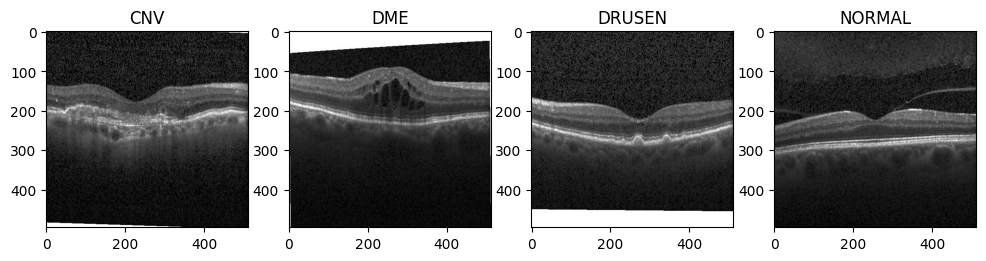

Sample testing data tensor
(Image([[[-1.8610, -1.5528, -1.7754,  ...,  2.1975,  2.2147,  2.2147],
        [-1.7069, -1.7754, -1.9467,  ...,  2.1975,  2.1975,  2.1804],
        [-1.6727, -1.7069, -1.8268,  ..., -0.5596, -0.5082, -0.8335],
        ...,
        [ 2.2489,  2.2489,  2.2489,  ..., -1.9980, -2.0837, -2.0837],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0323, -2.0837, -2.0665],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0494, -2.1008, -2.1179]],

       [[-1.7731, -1.4580, -1.6856,  ...,  2.3761,  2.3936,  2.3936],
        [-1.6155, -1.6856, -1.8606,  ...,  2.3761,  2.3761,  2.3585],
        [-1.5805, -1.6155, -1.7381,  ..., -0.4426, -0.3901, -0.7227],
        ...,
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9132, -2.0007, -2.0007],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9482, -2.0007, -1.9832],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9657, -2.0182, -2.0357]],

       [[-1.5430, -1.2293, -1.4559,  ...,  2.5877,  2.6051,  2.6051],
        [-1.3861, -1.4559, -1.63

In [5]:
# Testing Dataset Initialization
testing_data = OCTImageDataset(data_dir=test_data_dir, type='test')
testing_data.visualize()
print(f'Sample testing data tensor\n{testing_data[0]}')

# Testing Data Loader
testing_data_loader = DataLoader(dataset=testing_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 32 images for val set.
Visualizing dataset statistics for val set:
CNV: 8 images
DME: 8 images
DRUSEN: 8 images
NORMAL: 8 images


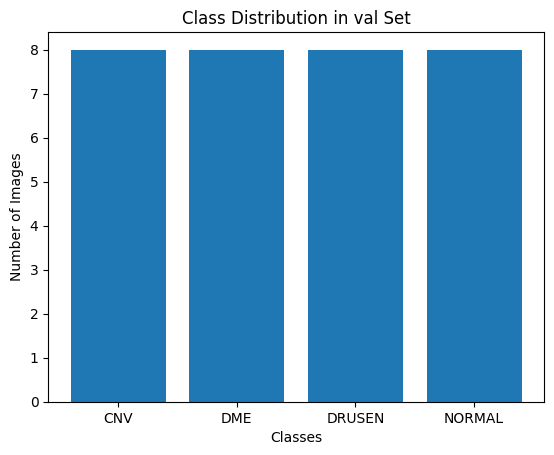

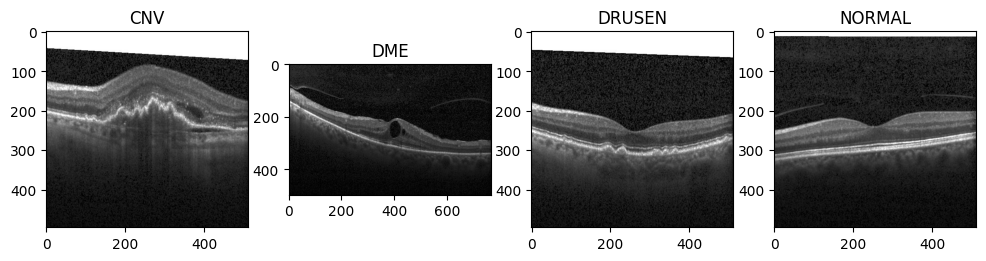

Sample validation data tensor
(Image([[[ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        ...,
        [-1.8097, -1.8610, -1.8268,  ..., -2.0494, -1.9467, -1.9809],
        [-1.7583, -1.8268, -1.7925,  ..., -1.9980, -1.9467, -1.9638],
        [-1.8268, -1.8953, -1.8439,  ..., -1.8782, -1.9980, -2.0494]],

       [[ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        ...,
        [-1.7206, -1.7731, -1.7381,  ..., -1.9657, -1.8606, -1.8957],
        [-1.6681, -1.7381, -1.7031,  ..., -1.9132, -1.8606, -1.8782],
        [-1.7381, -1.8081, -1.7556,  ..., -1.7906, -1.9132, -1.9657]],

       [[ 2.6400,  2.6400,  2.6400,  ...,  2.6400,  2.6400,  2.6400],
        [ 2.6400,  2.6400,  2

In [6]:
# Validation Dataset Initialization
val_data = OCTImageDataset(data_dir=val_data_dir, type='val')
val_data.visualize()
print(f'Sample validation data tensor\n{val_data[0]}')

# Training Data Loader
val_data_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=shuffle_data)

## Machine Learning Model: ResNet Transfer Learning

#### Resources Used

Despite not being required, we wanted to state the resources that we used to create the following ResNet-50 neurnal network model implementation.

- https://www.geeksforgeeks.org/deep-learning/how-to-implement-transfer-learning-in-pytorch/
- GitHub Copilot Autocomplete was used to help construct some sections of the code, in addition to helping autocomplete some redundent code elements that were already present in the code and just needed to be written again and writing the comments seen throughout the code. Since data is not available regarding the carbon emissions of GitHub Copilot autocomplete, I will be treating each autocomplete as a ChatGPT querry as GitHub Copilot is powered by ChatGPT. Therefore, using the provided metric of 4.32g of carbon emissions for a ChatGPT querry, we will be estimating my total carbon emission for using GitHub Copilot autocomplete for comments and writing redudent code at 4.32g x 30 = 129.6g.

**Total Carbon Emission Emerging from GitHub Copilot Autcomplete:** 216g

In [7]:
# ---------------------- ResNet-50 Model Initialization ----------------------

class CustomResNet(nn.Module):
    def __init__(self,):
        super(CustomResNet, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(self.resnet.children())[:-1])  # All layers except the final FC layer
        self.classifier = nn.Linear(self.resnet.fc.in_features, 4)  # New final layer for 4 classes

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# ------------------------ Training and Validation Phase ----------------------

def train_validate_model(model, training_data_loader, val_data_loader, device, optimizer, criterion, num_epochs):
    # Check if trained model already exists
    if os.path.exists('Trained_Model/trained_resnet50_1000_images.pth'):
        # Extracting the model and naming it model so it can be fine tuned and evaluated
        model_path = 'Trained_Model/trained_resnet50_1000_images.pth'
        model.load_state_dict(torch.load(model_path, map_location=device))

        # Moving model to the appropriate device
        model.to(device)

        print("Trained model already exists. Skipping training.")
    else:
        # Training and validation loss/accuracy counters
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []

        # Epoch numbers for plotting
        epochs_list = []

        # Going through each epoch
        for epoch in range(num_epochs):

            epochs_list.append(epoch + 1)

            # ---------------------- Training Phase ----------------------
            # Set model to training mode
            model.train()

            # Reset running loss, correct training amount, and total train amount for each epoch
            running_loss = 0.0
            train_correct = 0
            train_total = 0

            # Iterate over training data
            for images, labels in training_data_loader:
                # Move data to the appropriate device
                images, labels = images.to(device), labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Running forward pass
                outputs = model(images)

                # Compute loss and backpropagate
                loss = criterion(outputs, labels)
                loss.backward()

                # Update model parameters
                optimizer.step()

                # Update running loss and accuracy
                running_loss += loss.item()

                # Extracts predicted class index for each sample in the batch
                _, predicted = torch.max(outputs.data, 1)

                # Adds batch size to the running total number of samples processed
                train_total += labels.size(0)

                # Adds number of correct predictions to running total
                train_correct += (predicted == labels).sum().item()

            # Compute average loss and accuracy for the epoch
            avg_train_loss = running_loss / len(training_data_loader)
            train_losses.append(avg_train_loss)
            train_accuracy = train_correct / train_total
            train_accuracies.append(train_accuracy)

            # ---------------------- Validation Phase ----------------------
            # Initialize validation loss and accuracy counters
            val_running_loss = 0.0
            val_correct = 0
            val_total = 0
            
            # Set model to evaluation mode (Validation)
            model.eval()

            # Iterate over validation data while stopping gradient computation
            # This is important to prevent updating model parameters during validation
            # It also reduces memory consumption
            with torch.no_grad():
                for images, labels in val_data_loader:
                    # Move data to the appropriate device
                    images, labels = images.to(device), labels.to(device)

                    # Running forward pass
                    outputs = model(images)

                    # Compute loss
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item()

                    # Extracts predicted class index for each sample in the batch
                    _, predicted = torch.max(outputs.data, 1)

                    # Adding batch size to the running total number of samples processed
                    val_total += labels.size(0)

                    # Compares predicted labels to true labels and sums correct predictions
                    val_correct += (predicted == labels).sum().item()
            
            # Compute average loss and accuracy for validation
            val_loss = val_running_loss / len(val_data_loader)
            val_accuracy = val_correct / val_total
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
            
            # Printing epoch-wise performance
            print(f'Epoch [{epoch+1}/{num_epochs}]:')
            print(f'Training - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
            print(f'Validation - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')
        
        # Plot the training and validation loss over epochs
        plt.figure(figsize=(12, 5))
        plt.plot(epochs_list, train_losses, label='Training Loss', marker='o')
        plt.plot(epochs_list, val_losses, label='Validation Loss', marker='x')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Saving the model
        model_save_path = 'Trained_Model/trained_resnet50_1000_images.pth'
        torch.save(model.state_dict(), model_save_path)
        print(f'\nModel saved to {model_save_path}')

In [ ]:
# ------------------------ Testing Phase ----------------------

def test_model(model, testing_data_loader, device):
    # Correct and total for accuracy calculation
    correct = 0
    total = 0

    # Confusion matrix counters
    test_predicted_list = []
    test_labels_list = []

    # Testing Loop
    # Set model to evaluation mode (Testing)
    model.eval()

    # Iterate over testing data while stopping gradient computation
    # This is important to prevent updating model parameters during testing
    # It also reduces memory consumption
    with torch.no_grad():
        # Evaluate on test data
        for images, labels in testing_data_loader:
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Get model outputs
            outputs = model(images)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1) # Get the index of the maximum value

            # Store predicted and true labels for confusion matrix
            # Moving it to the cpu in case it was on gpu memory
            test_predicted_list.extend(predicted.cpu().numpy())
            test_labels_list.extend(labels.cpu().numpy())

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Final Test Accuracy
    test_accuracy = correct / total
    print(f'Final Test Accuracy: {test_accuracy:.4f}')

    print(f'\nConfusion Matrix after Testing:')
    cm = confusion_matrix(test_labels_list, test_predicted_list)
    matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
    matrix_display.plot()
    plt.title(f"Confusion Matrix for Testing Data")
    plt.show()

Using device: cuda

-----------------------------------------------------------------------------
------------------------ Training and Validation Phase ----------------------
-----------------------------------------------------------------------------
Epoch [1/10]:
Training - Train Loss: 1.0887, Train Accuracy: 0.5433
Validation - Val Loss: 0.6531, Val Accuracy: 0.7812
Epoch [2/10]:
Training - Train Loss: 0.7874, Train Accuracy: 0.7192
Validation - Val Loss: 0.5057, Val Accuracy: 0.8750
Epoch [3/10]:
Training - Train Loss: 0.6839, Train Accuracy: 0.7508
Validation - Val Loss: 0.4508, Val Accuracy: 0.8438
Epoch [4/10]:
Training - Train Loss: 0.6904, Train Accuracy: 0.7365
Validation - Val Loss: 0.3884, Val Accuracy: 0.9062
Epoch [5/10]:
Training - Train Loss: 0.6213, Train Accuracy: 0.7712
Validation - Val Loss: 0.3650, Val Accuracy: 0.9375
Epoch [6/10]:
Training - Train Loss: 0.6065, Train Accuracy: 0.7668
Validation - Val Loss: 0.3354, Val Accuracy: 0.9062
Epoch [7/10]:
Training - T

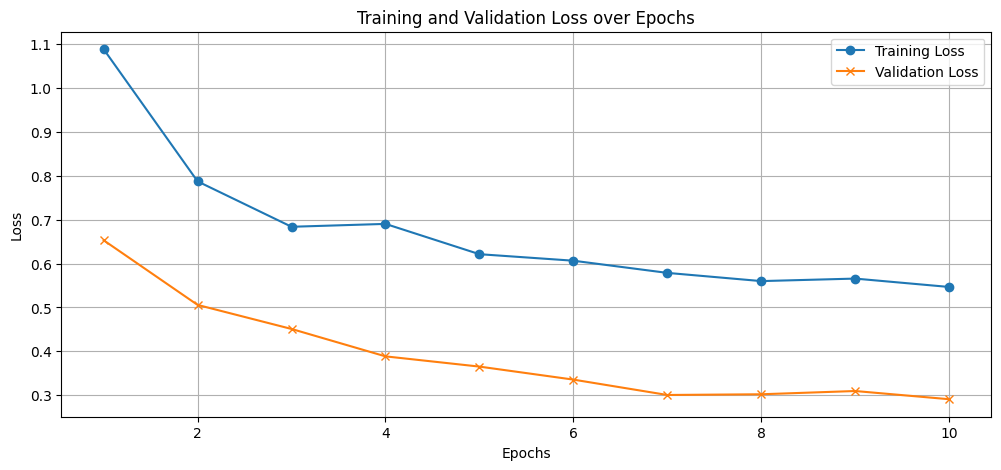


Model saved to Trained_Model/trained_resnet50_1000_images.pth

-----------------------------------------------------------------------------
------------------------------ Testing Phase --------------------------------
-----------------------------------------------------------------------------
Final Test Accuracy: 0.8357 testing accuracy.

Confusion Matrix after Testing:


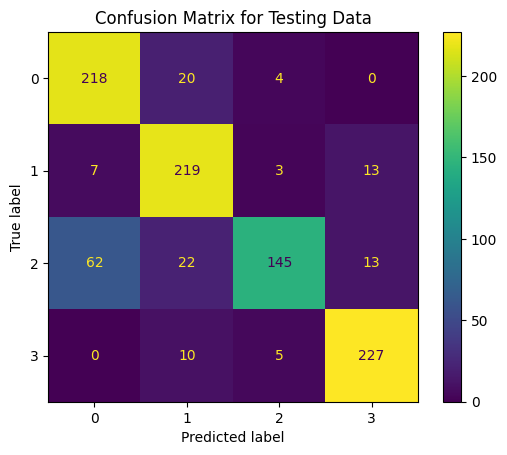

In [ ]:
# ------------------------ Main Execution ----------------------

if __name__ == '__main__':

    # Selecting the graphics card is available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # Instantiate the CustomResNet model, passing the pretrained model
    model = CustomResNet().to(device)

    # Freeze all layers except the final layer
    for param in model.parameters():
        param.requires_grad = False
    for param in model.resnet.layer4.parameters():
        param.requires_grad = True

    # Unfreeze the classifier layer allowing for fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Setting model hyperparameters
    num_epochs = 10
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

    # Train the model
    print(f"\n-----------------------------------------------------------------------------")
    print(f"------------------------ Training and Validation Phase ----------------------")
    print(f"-----------------------------------------------------------------------------")
    # Train and validate the model
    train_validate_model(model, training_data_loader, val_data_loader, device, optimizer, criterion, num_epochs)

    print(f"\n-------------------------------------------------------------------------------")
    print(f"------------------------------- Testing Phase ---------------------------------")
    print(f"-------------------------------------------------------------------------------")
    # Test the model
    test_model(model, testing_data_loader, device)